In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [7]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

# Define your transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

file_path = '/content/archive.zip'

# Check if CIFAR-10 already exists in the expected location
if os.path.exists('./data/cifar-10-batches-py'):
    print("CIFAR-10 already extracted!")

else:
    # Create data directory
    os.makedirs('./data', exist_ok=True)

    # Try to identify and extract the file
    with open(file_path, 'rb') as f:
        header = f.read(4)

    # Check file signature
    if header[:4] == b'PK\x03\x04':
        # ZIP file
        import zipfile
        print("Detected ZIP file. Extracting...")
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall('./data')

    elif header[:2] == b'\x1f\x8b':
        # GZIP file (likely tar.gz)
        import tarfile
        print("Detected GZIP file. Extracting...")
        with tarfile.open(file_path, 'r:gz') as tar_ref:
            tar_ref.extractall('./data')

    else:
        # Might be a direct pickle file or rename the file
        print("Unknown format. Trying to use as-is...")
        # Try renaming to what PyTorch expects
        import shutil
        target = './data/cifar-10-python.tar.gz'
        shutil.copy(file_path, target)
        print(f"Copied to {target}")

# Now load the dataset
try:
    train_dataset = datasets.CIFAR10(root='./data',
                                      train=True,
                                      download=False,  # Don't download
                                      transform=transform)

    dataloader = torch.utils.data.DataLoader(train_dataset,
                                              batch_size=32,
                                              shuffle=True)

    print(f"Success! Dataset loaded with {len(train_dataset)} samples")

except Exception as e:
    print(f"Error loading dataset: {e}")
    print("\nTrying with download=True as fallback...")

    # Fallback: let PyTorch download it properly
    train_dataset = datasets.CIFAR10(root='./data',
                                      train=True,
                                      download=True,  # Let it download fresh
                                      transform=transform)
    dataloader = torch.utils.data.DataLoader(train_dataset,
                                              batch_size=32,
                                              shuffle=True)
    print(f"Successfully downloaded! Dataset loaded with {len(train_dataset)} samples")

Detected ZIP file. Extracting...
Success! Dataset loaded with 50000 samples


In [8]:
latent_dim = 100
lr = 0.0002
beta1 = 0.5
beta2 = 0.999
num_epochs = 10

In [9]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128 * 8 * 8),
            nn.ReLU(),
            nn.Unflatten(1, (128, 8, 8)),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128, momentum=0.78),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64, momentum=0.78),
            nn.ReLU(),
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img

In [10]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.25),
        nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
        nn.ZeroPad2d((0, 1, 0, 1)),
        nn.BatchNorm2d(64, momentum=0.82),
        nn.LeakyReLU(0.25),
        nn.Dropout(0.25),
        nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(128, momentum=0.82),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.25),
        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256, momentum=0.8),
        nn.LeakyReLU(0.25),
        nn.Dropout(0.25),
        nn.Flatten(),
        nn.Linear(256 * 5 * 5, 1),
        nn.Sigmoid()
    )

    def forward(self, img):
        validity = self.model(img)
        return validity

In [11]:
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

adversarial_loss = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters()\
                         , lr=lr, betas=(beta1, beta2))
optimizer_D = optim.Adam(discriminator.parameters()\
                         , lr=lr, betas=(beta1, beta2))

Epoch [1/10]                        Batch 100/1563 Discriminator Loss: 0.4972 Generator Loss: 1.1811
Epoch [1/10]                        Batch 200/1563 Discriminator Loss: 0.5939 Generator Loss: 1.1636
Epoch [1/10]                        Batch 300/1563 Discriminator Loss: 0.7710 Generator Loss: 0.9633
Epoch [1/10]                        Batch 400/1563 Discriminator Loss: 0.5309 Generator Loss: 1.3538
Epoch [1/10]                        Batch 500/1563 Discriminator Loss: 0.6091 Generator Loss: 1.0040
Epoch [1/10]                        Batch 600/1563 Discriminator Loss: 0.5942 Generator Loss: 0.9098
Epoch [1/10]                        Batch 700/1563 Discriminator Loss: 0.6368 Generator Loss: 0.9767
Epoch [1/10]                        Batch 800/1563 Discriminator Loss: 0.6555 Generator Loss: 1.2102
Epoch [1/10]                        Batch 900/1563 Discriminator Loss: 0.7560 Generator Loss: 0.9747
Epoch [1/10]                        Batch 1000/1563 Discriminator Loss: 0.5839 Generator Lo

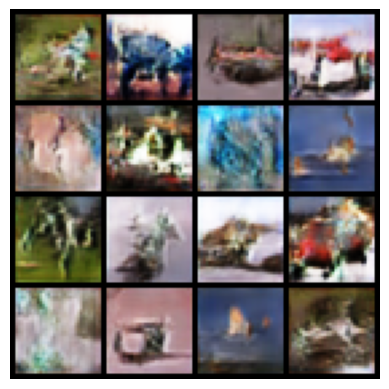

In [12]:
for epoch in range(num_epochs):
    for i, batch in enumerate(dataloader):

        real_images = batch[0].to(device)

        valid = torch.ones(real_images.size(0), 1, device=device)
        fake = torch.zeros(real_images.size(0), 1, device=device)

        real_images = real_images.to(device)

        optimizer_D.zero_grad()

        z = torch.randn(real_images.size(0), latent_dim, device=device)

        fake_images = generator(z)

        real_loss = adversarial_loss(discriminator\
                                     (real_images), valid)
        fake_loss = adversarial_loss(discriminator\
                                     (fake_images.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

        optimizer_G.zero_grad()

        gen_images = generator(z)

        g_loss = adversarial_loss(discriminator(gen_images), valid)
        g_loss.backward()
        optimizer_G.step()

        if (i + 1) % 100 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}]\
                        Batch {i+1}/{len(dataloader)} "
                f"Discriminator Loss: {d_loss.item():.4f} "
                f"Generator Loss: {g_loss.item():.4f}"
            )
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            z = torch.randn(16, latent_dim, device=device)
            generated = generator(z).detach().cpu()
            grid = torchvision.utils.make_grid(generated,\
                                        nrow=4, normalize=True)
            plt.imshow(np.transpose(grid, (1, 2, 0)))
            plt.axis("off")
            plt.show()